# Simulation Analysis

This file is to be used to analyse observable quantities of a simulation

In [113]:

import sys
from pathlib import Path

if sys.platform == "darwin":
    proj = "/Users/rileymcnamara/CODE/2025/silicokit/"
    sys.path.insert(0, proj)
else:
    proj = "C:/Users/riley.mcnamara/Documents/code/silicokit/"
    sys.path.insert(0, proj)

from src.growkit.PlotEngine.SimPlotter import SimPlotter
from src.growkit.PlotEngine.CellFieldPlotter import CellFieldPlotter
from src.growkit.Simulator import TumorGrowthSimulator

simulator = TumorGrowthSimulator(proj + "/configs/T_N.yaml")

simulation_data = simulator.load_simulation_data(proj + "/laboratory/saved_simulations/simulation_data.npz")

sim_plotter = SimPlotter(simulation_data)
cell_plotter = CellFieldPlotter(simulation_data, simulator=simulator)


Pre-compiling Numba functions...
Numba functions compiled successfully!
Loading simulation data from /Users/rileymcnamara/CODE/2025/silicokit//laboratory/saved_simulations/simulation_data.npz...
Loaded simulation data with 21 saved steps


## Radius Evolution

Calculating tumor radius evolution...
Calculating inhibited radius evolution...
Calculating necrotic radius evolution...
Calculating hypoxic radius evolution...


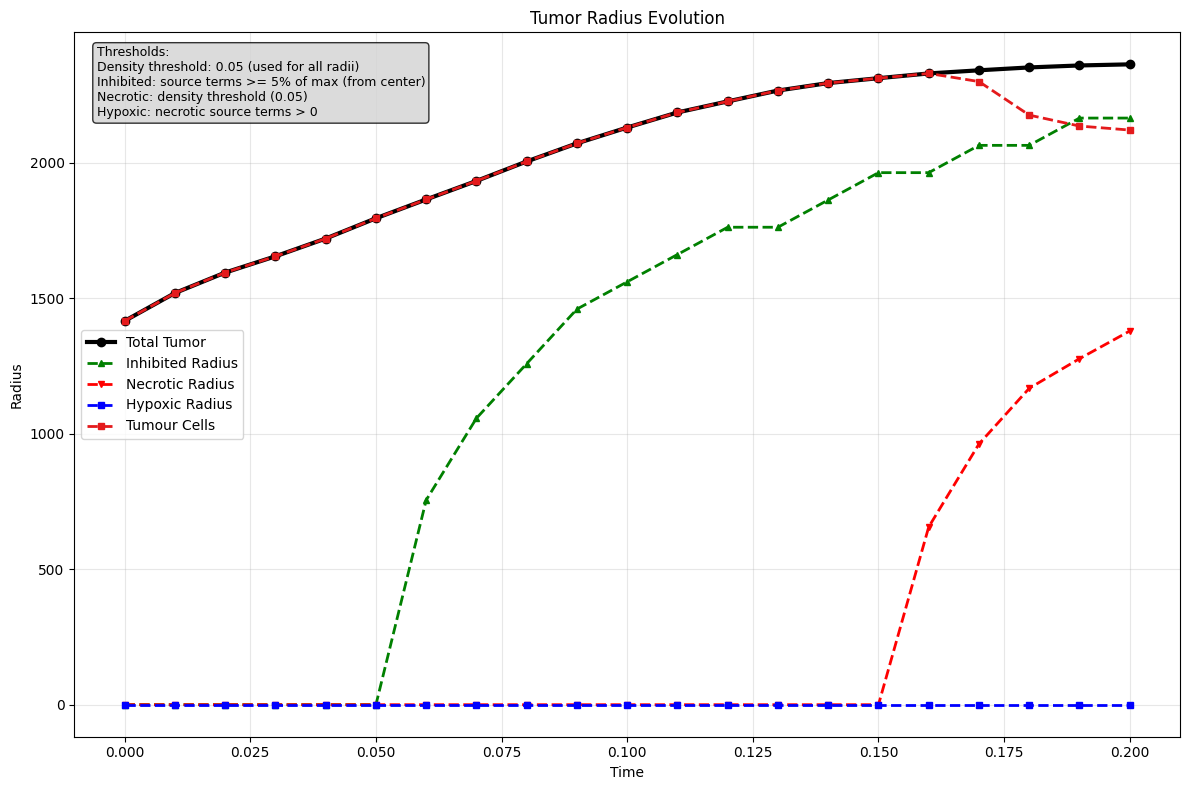

{'total_radii': [np.float64(1416.8249544469027),
  np.float64(1519.7155577111032),
  np.float64(1595.2473885760148),
  np.float64(1655.3021980531644),
  np.float64(1720.8414260446914),
  np.float64(1795.7585951539593),
  np.float64(1865.2050603926255),
  np.float64(1933.5777772352073),
  np.float64(2005.4874987065484),
  np.float64(2072.3106342912574),
  np.float64(2130.7519569234923),
  np.float64(2186.359391551518),
  np.float64(2227.2171642706676),
  np.float64(2267.320816350286),
  np.float64(2294.8730789032647),
  np.float64(2312.862884697447),
  np.float64(2330.417178487464),
  np.float64(2341.974713461496),
  np.float64(2352.5978105396066),
  np.float64(2359.874162151368),
  np.float64(2363.9681485083524)],
 'population_radii': {'Tumour Cells': [np.float64(1416.8249544469027),
   np.float64(1519.7155590445411),
   np.float64(1595.2473930253077),
   np.float64(1655.3022111072821),
   np.float64(1720.8414579518446),
   np.float64(1795.75865042392),
   np.float64(1865.205145094605)

In [114]:
sim_plotter.plot_tumor_radius_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(12, 8), include_individual_populations=True, threshold=0.05, method='contour', growth_threshold=0.45)

In [115]:
#sim_plotter.plot_density_and_source_with_radii()

## Population Density Evolution

Plotting evolution for population: Tumour Cells (index: 0)
Available population labels: ['Tumour Cells', 'Necrotic Cells']
Step indices: [0, 1, 3, 5, 7, 9, 10, 12, 14, 16, 18, 20]


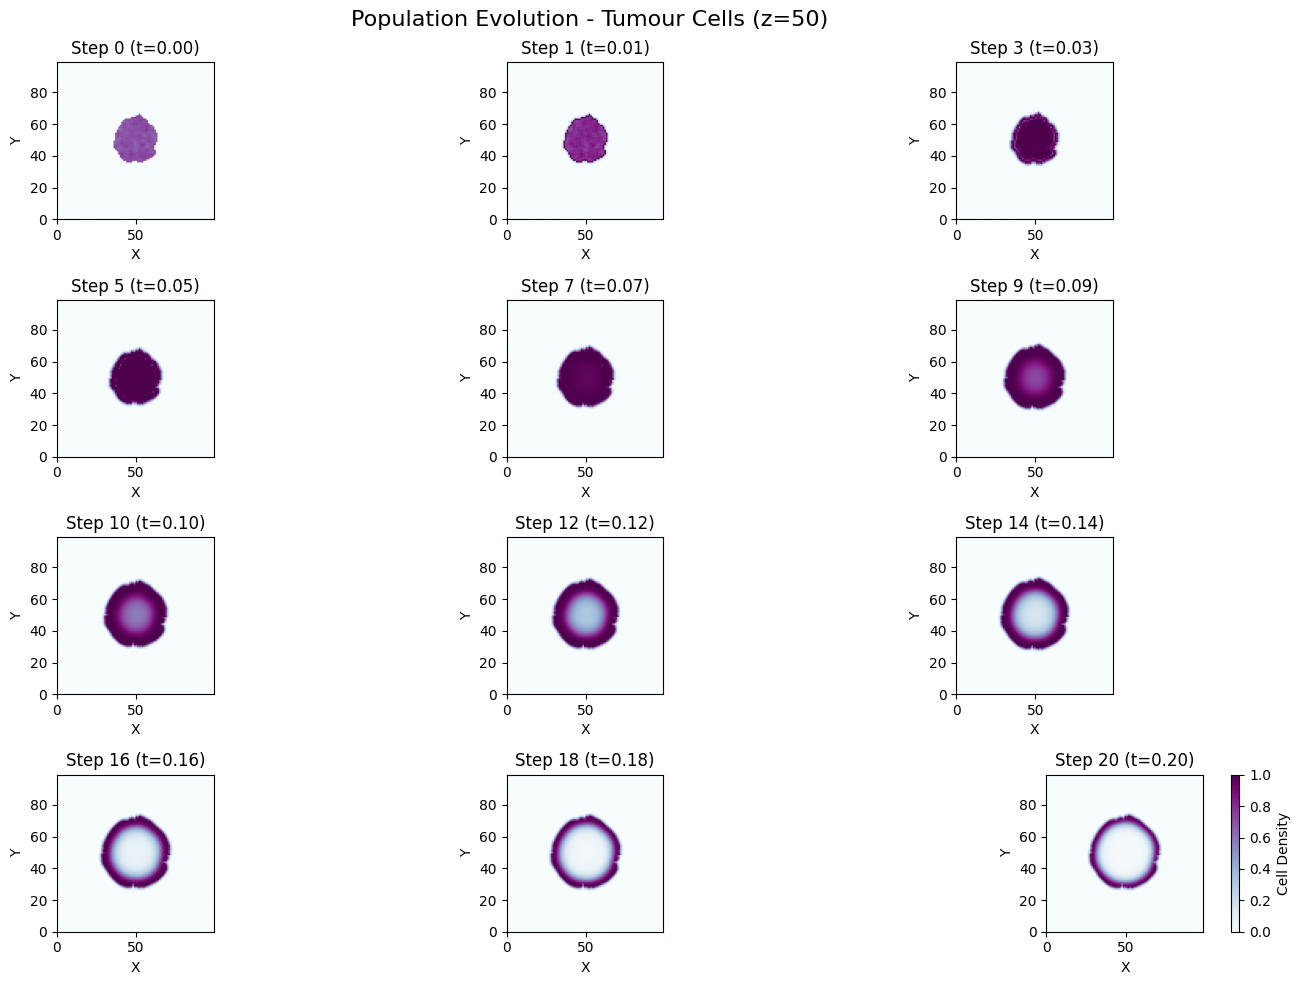

In [116]:
cell_plotter.plot_population_evolution_by_label(simulation_data, label="Tumour Cells", cmap="BuPu", show_plot=True)

Plotting evolution for population: Necrotic Cells (index: 1)
Available population labels: ['Tumour Cells', 'Necrotic Cells']
Step indices: [0, 1, 3, 5, 7, 9, 10, 12, 14, 16, 18, 20]


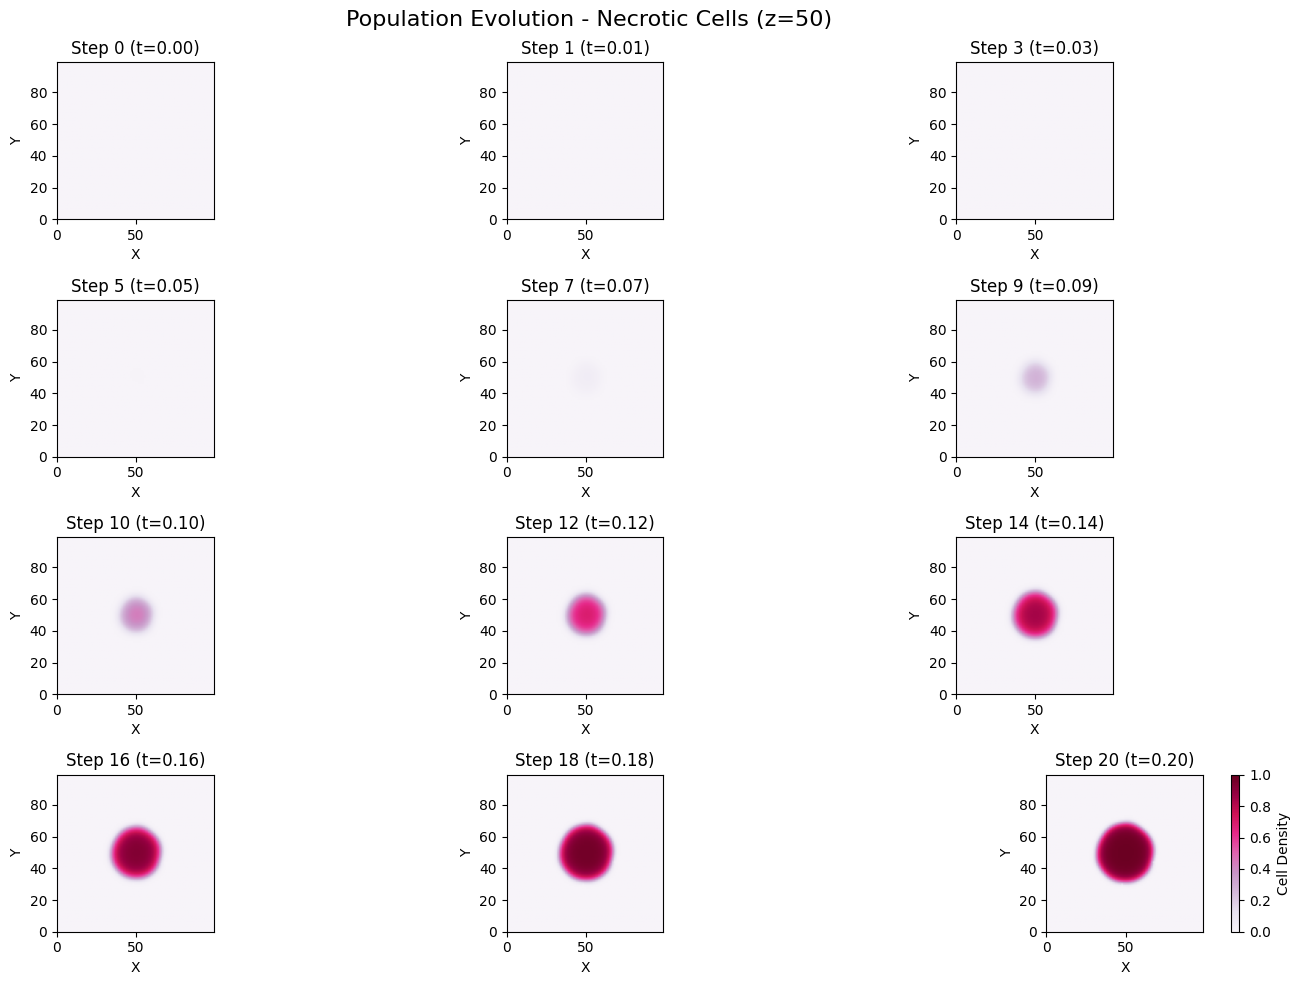

In [117]:
cell_plotter.plot_population_evolution_by_label(simulation_data, label="Necrotic Cells", cmap="PuRd", show_plot=True)

Creating nutrient field evolution plot...


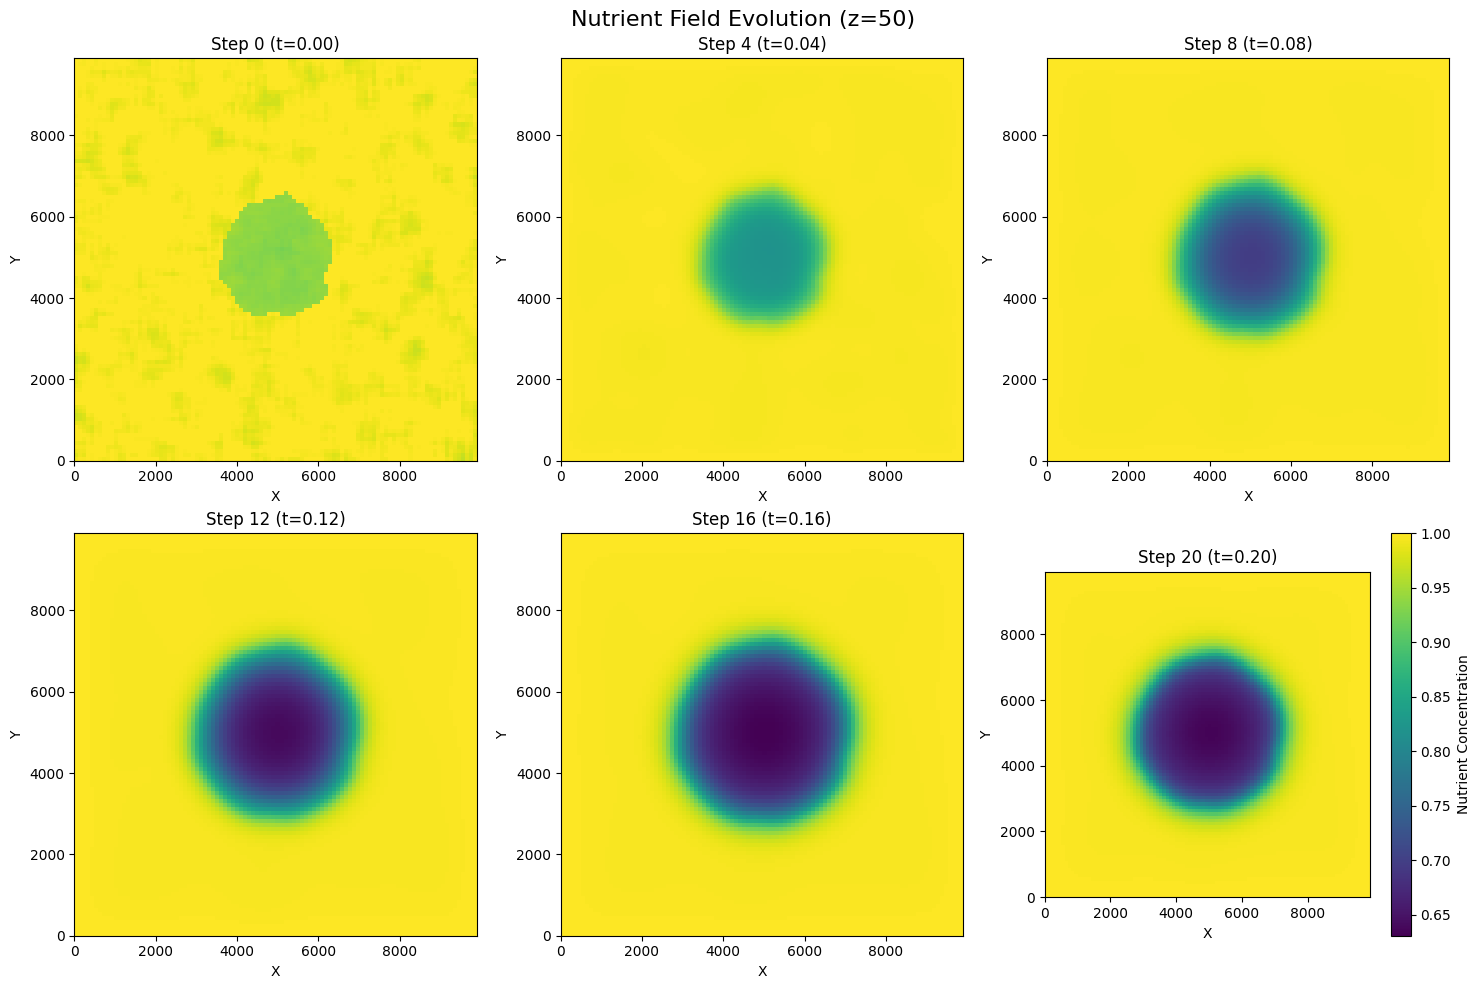

In [118]:
sim_plotter.plot_nutrient_field_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(15, 10), z_slice=None, cmap="viridis", add_tumor_contours=False, tumor_threshold=0.1, max_plots=6, include_statistics=False)

Creating source field evolution plot...


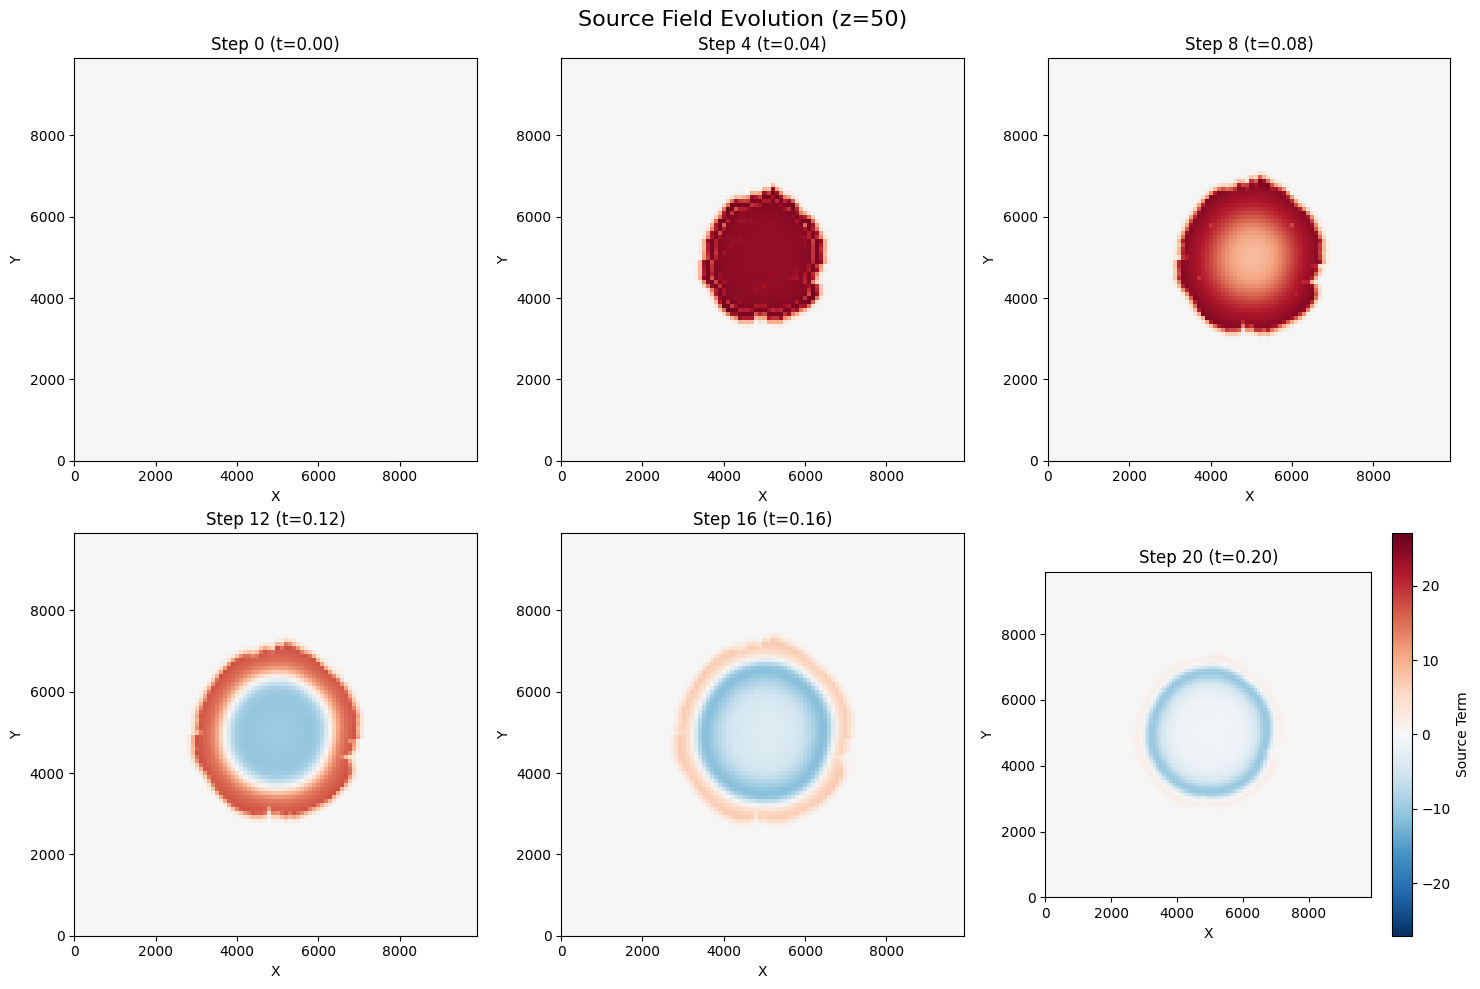

In [119]:
sim_plotter.plot_source_field_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(15, 10), z_slice=None, cmap="RdBu_r", add_tumor_contours=False, tumor_threshold=0.1, max_plots=6, include_statistics=False)

Creating radius diagnostic plot...
Radius diagnostic plot saved to path/to/output/radius_diagnostic_z50_threshold0.1.png


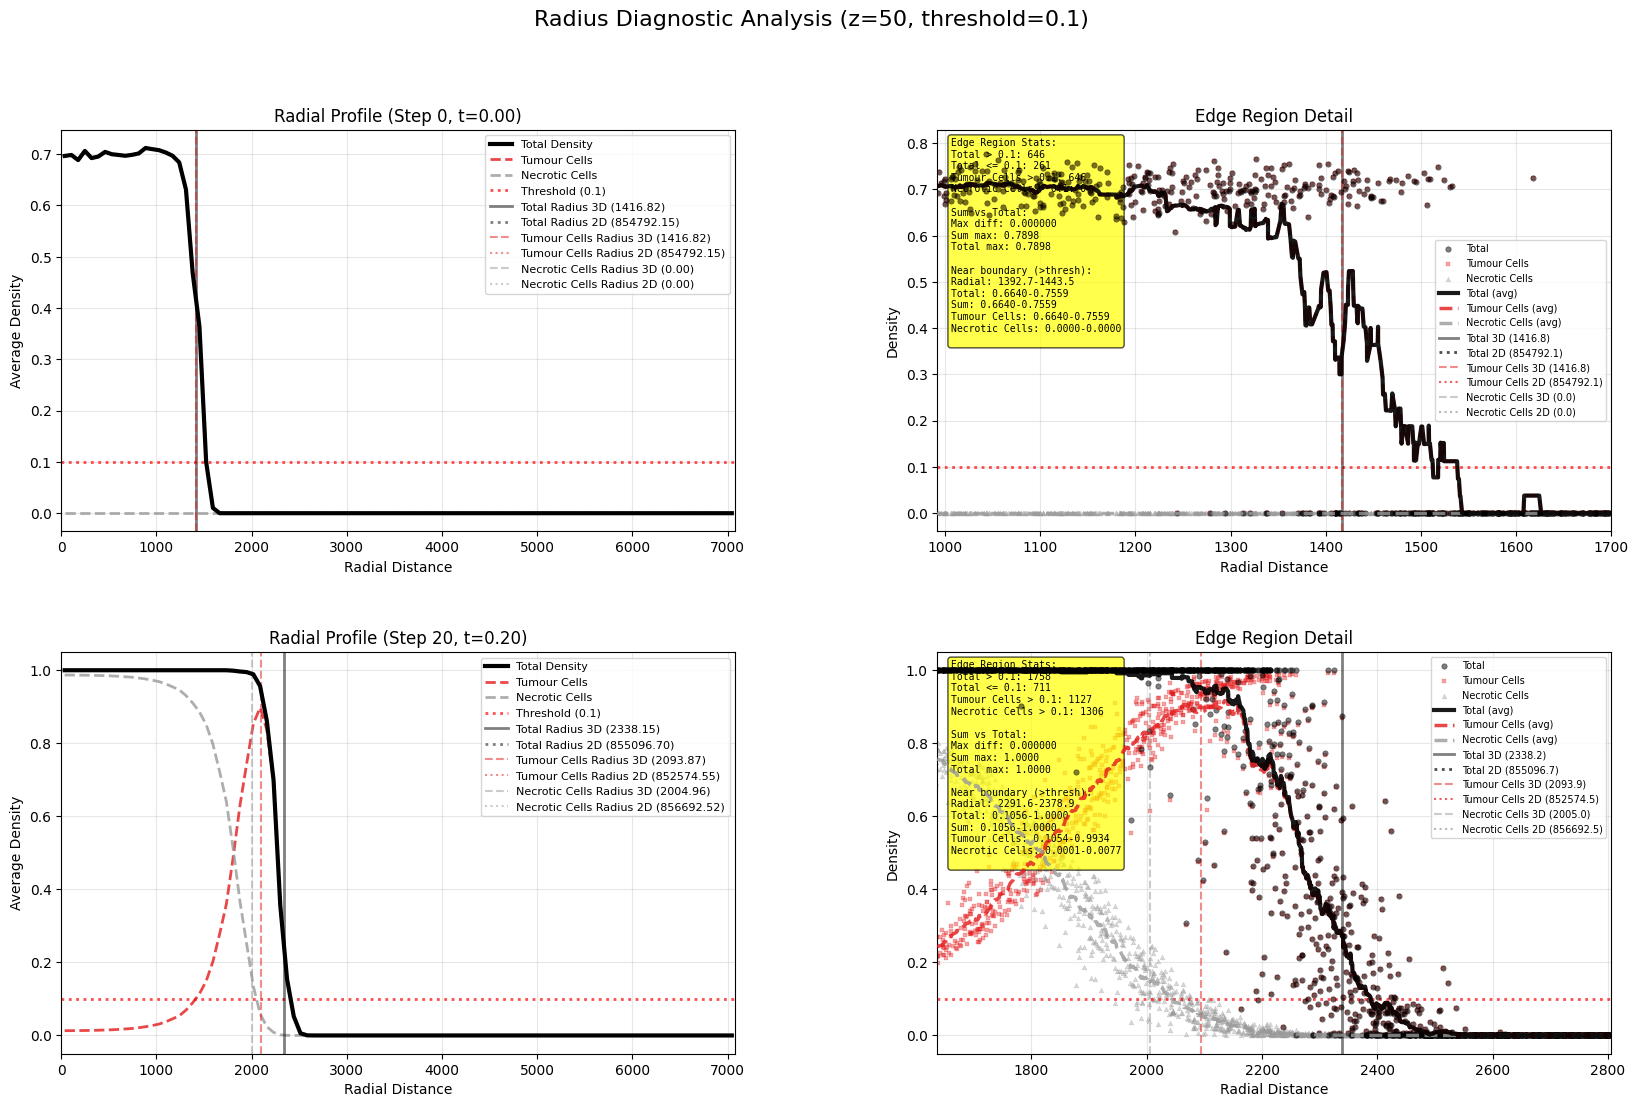

{'step_indices': [0, 20],
 'individual_radii': {0: {'Tumour Cells': np.float64(1416.8249544469027),
   'Necrotic Cells': 0.0},
  20: {'Tumour Cells': np.float64(2093.8703258092405),
   'Necrotic Cells': np.float64(2004.9622992720942)}},
 'total_radii': {0: np.float64(1416.8249544469027),
  20: np.float64(2338.154213003138)},
 'z_slice': 50,
 'threshold': 0.1,
 'total_radii_2d': {0: np.float64(854792.1498747093),
  20: np.float64(855096.6950761209)},
 'individual_radii_2d': {0: {'Tumour Cells': np.float64(854792.1498747093),
   'Necrotic Cells': 0.0},
  20: {'Tumour Cells': np.float64(852574.5461558407),
   'Necrotic Cells': np.float64(856692.5239056186)}}}

In [120]:
# In your notebook or script:
sim_plotter.plot_radius_diagnostic(
    output_dir='path/to/output',
    save_plot=True,
    step_indices=[0, 50, -1],  # Compare early, middle, and late time steps
    threshold=0.1,  # Use the same threshold as your radius plot
    method='contour'
)